<a href="https://colab.research.google.com/github/ionikim/epilepsy_pediatrics_EEG/blob/main/src/01_loading/preprocessing_140326_variable_changed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### EEG Data Preprocessing and Preparation for Graph Creation

In this file, we do the following (for file chb01_01):
1) load data
2) filter data (1-45 Hz)
4) re-reference data
5) transform into 2D array (rows = time points, columns = electrodes)
6) segment the data into 5-second windows
7) get average power from 5-second windows in order to reduce data points

Eye artifact removal (usually also part of EEG preprocessing) is not possible since no data from eye electrodes is available.

Next step: depends on graph type we want to construct, maybe HVG

In [2]:
from google.colab import files
uploaded = files.upload()

Saving chb01_01.edf to chb01_01.edf


In [4]:
!pip install mne
import mne
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## loading data

In [7]:
# load file 01
raw_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)
raw_data_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)._data
# print(raw_data_01)

Extracting EDF parameters from chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...


/tmp/ipykernel_768/1048083340.py:2: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)


Reading 0 ... 921599  =      0.000 ...  3599.996 secs...
Extracting EDF parameters from chb01_01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 921599  =      0.000 ...  3599.996 secs...


/tmp/ipykernel_768/1048083340.py:3: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw_data_01 = mne.io.read_raw_edf('chb01_01.edf', preload=True)._data


Number of channels:  23
Number of samples:  921600


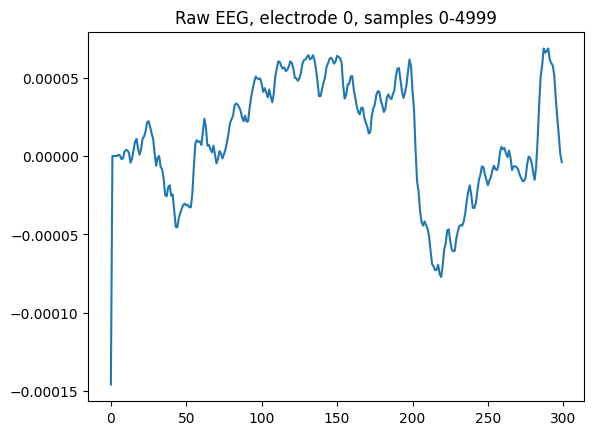

In [8]:
# test

print("Number of channels: ", str(len(raw_data_01)))
print("Number of samples: ", str(len(raw_data_01[0])))

plt.plot(raw_data_01[0,:300])
plt.title("Raw EEG, electrode 0, samples 0-4999")
plt.show()

## filtering data

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 845 samples (3.301 s)

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_768/504035306.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_01.compute_psd(fmax=60).plot()


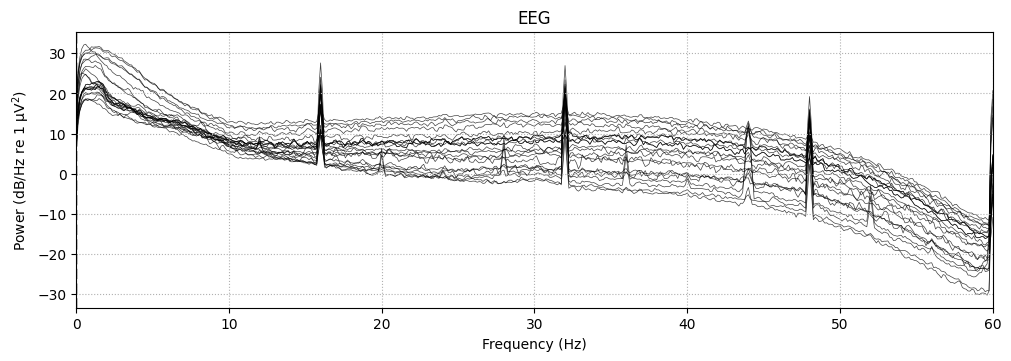

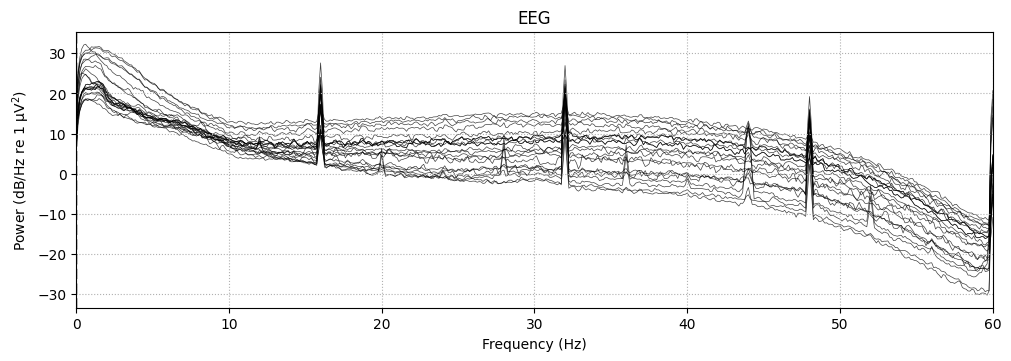

In [9]:
# Apply bandpass filter from 1-45 Hz
filtered_raw_01 = raw_01.copy().filter(l_freq=1, h_freq=45)

# visualize results: power spectral density before and after filtering

# before filtering
raw_01.compute_psd(fmax=60).plot()

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_768/3311281567.py:2: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  filtered_raw_01.compute_psd(fmax=60).plot()


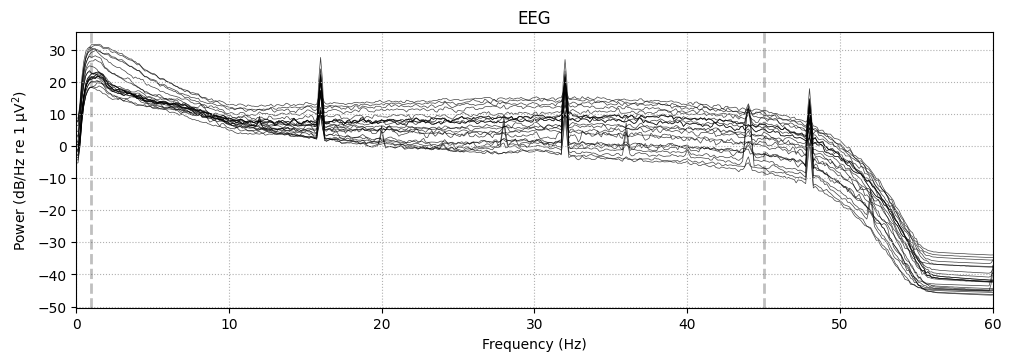

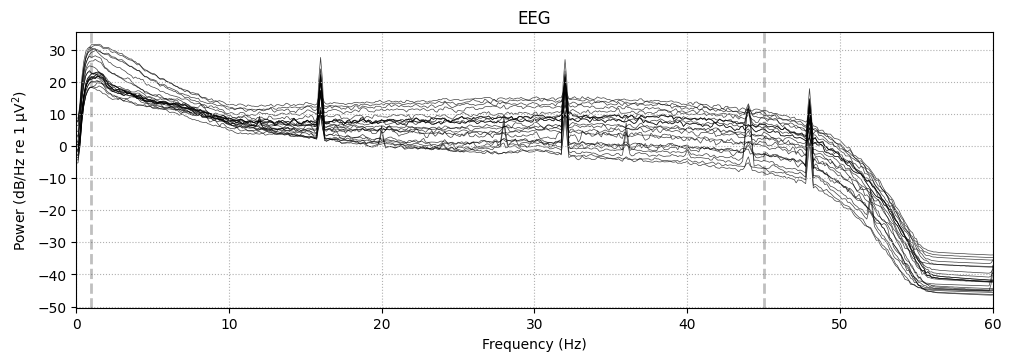

In [10]:
# after filtering
filtered_raw_01.compute_psd(fmax=60).plot()

## re-referencing data

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Using matplotlib as 2D backend.


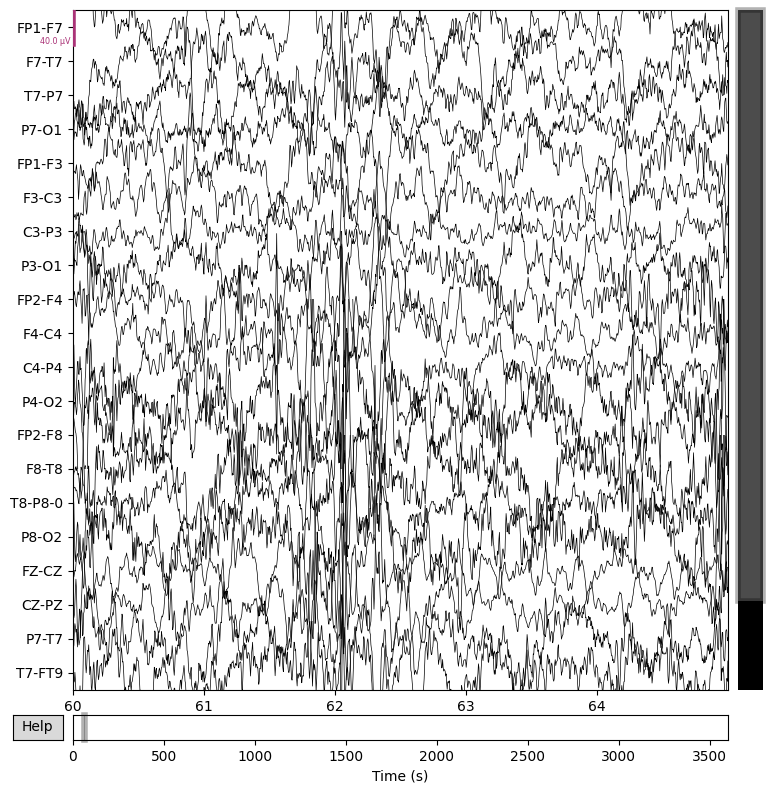

In [11]:
raw_01_reref = raw_01.set_eeg_reference('average')
_ = raw_01_reref.plot(start=60.0, duration=5.0)

## creating an array

In [12]:
# get electrode names
electrode_names = raw_01.ch_names

# print names to verify
# print(electrode_names)

# get sampling frequency
sfreq = raw_01.info['sfreq']

# calculate time points in seconds
n_samples = len(raw_01.times)
time_marks = np.arange(n_samples) / sfreq

#[before]
# electrode data (rows = electrodes, columns = time points)
# The filter was defined as 'filtered_raw_01', but the data was
# extracted from the unfiltered 'raw_01' object.
# Result: The 1-45Hz band-pass filter might NOT be applied to the analysis.
#
# electrode_data = raw_01.get_data()

#[suggestion]
# [FIX] Use filtered_raw_01 instead of raw_01 to ensure the
# 1-45Hz band-pass filter is actually applied to the analysis.
#
electrode_data = filtered_raw_01.get_data()

#  DataFrame, transpose electrode_data so each column is an electrode
df = pd.DataFrame(electrode_data.T, columns=electrode_names)

# time as index
df.index = time_marks
df.index.name = 'Time (s)'

# check
# display(df)
#print(df.iloc[:20,:7])

## segmenting into 5 second windows

In [13]:
window_size = 5  # seconds

# add window labels (0-5s = 0, 5-10s = 1, etc.) to df
df['window'] = (df.index // window_size).astype(int)

# check -> 720*5 seconds = 3600s = 1h = length of recording
display(df)

,FP1-F7,F7-T7,T7-P7,P7-O1,FP1-F3,F3-C3,C3-P3,P3-O1,FP2-F4,F4-C4,...,T8-P8-0,P8-O2,FZ-CZ,CZ-PZ,P7-T7,T7-FT9,FT9-FT10,FT10-T8,T8-P8-1,window
Time (s),,,,,,,,,,,,,,,,,,,,,
0.000000,-3.811648e-20,-3.388132e-21,-8.470329e-21,-3.388132e-21,-1.016440e-20,-1.694066e-21,5.929231e-21,1.694066e-21,-4.912791e-20,3.388132e-21,...,1.524659e-20,2.879912e-20,-1.694066e-20,2.625802e-20,1.355253e-20,-2.032879e-20,-4.404571e-20,-5.082198e-21,1.524659e-20,0
0.003906,9.966914e-05,7.142103e-05,3.002494e-05,2.306671e-05,1.167752e-04,7.619286e-05,-8.223175e-06,3.928829e-05,9.533704e-05,8.052273e-07,...,-3.087546e-05,-5.479795e-05,7.270296e-05,-5.800660e-05,-3.002494e-05,3.813283e-05,1.844833e-04,-6.406678e-05,-3.087546e-05,0
0.007812,1.564645e-04,1.123920e-04,4.623872e-05,3.611471e-05,1.833888e-04,1.191339e-04,-1.279147e-05,6.121660e-05,1.495602e-04,1.445108e-06,...,-4.799048e-05,-8.431393e-05,1.140815e-04,-9.077958e-05,-4.623872e-05,6.028969e-05,2.871709e-04,-1.010714e-04,-4.799048e-05,0
0.011719,1.616911e-04,1.160518e-04,4.679242e-05,3.672245e-05,1.894211e-04,1.223197e-04,-1.300065e-05,6.230047e-05,1.542265e-04,1.685827e-06,...,-4.882787e-05,-8.241298e-05,1.175820e-04,-9.331657e-05,-4.679242e-05,6.375051e-05,2.914805e-04,-1.050701e-04,-4.882787e-05,0
0.015625,1.417617e-04,1.005250e-04,4.126001e-05,3.100230e-05,1.655885e-04,1.066728e-04,-1.123018e-05,5.358666e-05,1.348105e-04,1.375667e-06,...,-4.234568e-05,-6.536044e-05,1.024582e-04,-8.145770e-05,-4.126001e-05,5.835994e-05,2.495667e-04,-9.219720e-05,-4.234568e-05,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3599.980469,1.983159e-06,-1.734806e-05,1.162293e-05,2.907287e-05,-1.693643e-06,-3.813050e-05,1.298575e-05,5.164746e-05,9.809259e-07,3.687276e-07,...,-4.643581e-06,-1.504818e-05,-1.052749e-05,-5.095246e-06,-1.162293e-05,-3.816324e-05,5.643506e-05,2.117714e-05,-4.643581e-06,719
3599.984375,-2.034634e-05,-1.130920e-05,1.716406e-05,1.849351e-05,-2.489332e-05,-2.715582e-05,1.854413e-05,3.700945e-05,-1.551710e-06,-2.082644e-06,...,-7.782328e-06,-2.051116e-05,-4.439647e-06,-2.234165e-06,-1.716406e-05,-3.175968e-05,5.407380e-05,1.608545e-05,-7.782328e-06,719
3599.988281,-3.254619e-05,-5.472319e-06,1.768386e-05,7.492507e-06,-3.744946e-05,-1.162728e-05,1.750761e-05,1.836949e-05,-1.774902e-06,-3.248336e-06,...,-8.251476e-06,-1.689856e-05,-9.783584e-08,2.012440e-06,-1.768386e-05,-1.728166e-05,3.622556e-05,7.346849e-06,-8.251476e-06,719


In [14]:
# create a new array -> each cell contains an array of values for that 5s window
df_windows = df.groupby('window').agg(list)
#display(df_windows)

df_windows.iloc[:5, 1:2]
print(df_windows.shape) # 720 windows, 23 electrodes

(720, 23)


## calculating power of 5-second windows
in order to reduce data points:
from 921600 time points × 23 electrodes (21'196'800 nodes) to 720 time points to 23 electrodes (16'560 nodes)

Since EEG data naturally oscillates around 0 Volt, power ($\frac{1}{N}\sum_{i=1}^{N} x_i^2$) was calculated for each window in order to

1) get rid of negative values
2) penalize bigger oscillations

In [15]:
window_powers_df = []

for value in df_windows:
    window_powers = []
    for row_list in df_windows[value]:
        window_power = np.mean([x**2 for x in row_list])
        window_powers.append(window_power)
    window_powers_df.append(window_powers)

window_powers_df = pd.DataFrame(window_powers_df)
window_powers_df.columns = df_windows.index
window_powers_df.index = electrode_names

#display(result_sums)